In [69]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [70]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

In [71]:
image_ds = tf.data.Dataset.list_files("data/kitti/training/image_2/*.png", shuffle=False)
mask_ds = tf.data.Dataset.list_files("data/kitti/training/semantic/*.png", shuffle=False)
dataset = tf.data.Dataset.zip((image_ds, mask_ds))

In [72]:
for path in image_ds.take(5):
    print(path.numpy())

b'data/kitti/training/image_2/000000_10.png'
b'data/kitti/training/image_2/000001_10.png'
b'data/kitti/training/image_2/000002_10.png'
b'data/kitti/training/image_2/000003_10.png'
b'data/kitti/training/image_2/000004_10.png'


In [73]:
for path in mask_ds.take(5):
    print(path.numpy())

b'data/kitti/training/semantic/000000_10.png'
b'data/kitti/training/semantic/000001_10.png'
b'data/kitti/training/semantic/000002_10.png'
b'data/kitti/training/semantic/000003_10.png'
b'data/kitti/training/semantic/000004_10.png'


In [74]:
from data.devkit_semantics.devkit.helpers.labels import labels

mapping = np.full(256, 255, dtype=np.int32)
for label in labels:
    if label.id >= 0:
        mapping[label.id] = label.trainId
mapping[mapping == 255] = 19

In [75]:
def load_preprocess(image_path, mask_path):
    raw_image = tf.io.read_file(image_path)
    raw_mask = tf.io.read_file(mask_path)

    decoded_image = tf.image.decode_png(raw_image, channels=3)
    decoded_mask = tf.image.decode_png(raw_mask, channels=1)

    resized_image = tf.image.resize(decoded_image, [128,384])
    resized_mask = tf.image.resize(decoded_mask, [128,384], method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)

    label_mapping = tf.constant(mapping, dtype=tf.int32)
    resized_mask = tf.gather(label_mapping, tf.cast(resized_mask, tf.int32))

    resized_image = resized_image / 255.0

    return resized_image, resized_mask

In [76]:
dataset = dataset.map(load_preprocess)

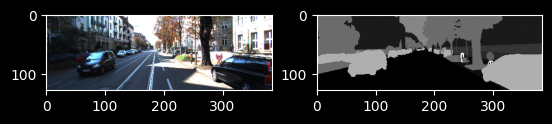

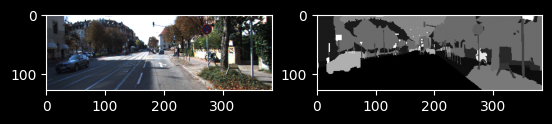

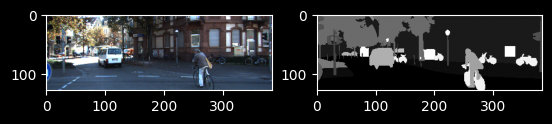

In [77]:
for feature, label in dataset.take(3):
    fig, (ax1, ax2) = plt.subplots(1, 2)
    ax1.imshow(feature)
    ax2.imshow(tf.squeeze(label), cmap='gray')
    plt.show()

In [102]:
batch_size = 8
train_ds = dataset.take(160).shuffle(160).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_ds = dataset.skip(160).batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [103]:
import importlib
import unet
importlib.reload(unet)
from unet import build_unet

In [104]:
model = build_unet((128,384, 3), 20)
model.summary()

Model: "unet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 128, 384,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_119 (Conv2D) │ (None, 128, 384,  │      1,792 │ input_layer_7[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_120 (Conv2D) │ (None, 128, 384,  │     36,928 │ conv2d_119[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_28    │ (None, 64, 192,   │          0 │ conv2d_120[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_121 (Conv2D) │ (None, 64, 192,   │     73,856 │ max_pooling2d_28… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_122 (Conv2D) │ (None, 64, 192,   │    147,584 │ conv2d_121[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_29    │ (None, 32, 96,    │          0 │ conv2d_122[0][0]  │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_123 (Conv2D) │ (None, 32, 96,    │    295,168 │ max_pooling2d_29… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_124 (Conv2D) │ (None, 32, 96,    │    590,080 │ conv2d_123[0][0]  │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_30    │ (None, 16, 48,    │          0 │ conv2d_124[0][0]  │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_125 (Conv2D) │ (None, 16, 48,    │  1,180,160 │ max_pooling2d_30… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_126 (Conv2D) │ (None, 16, 48,    │  2,359,808 │ conv2d_125[0][0]  │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_31    │ (None, 8, 24,     │          0 │ conv2d_126[0][0]  │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_127 (Conv2D) │ (None, 8, 24,     │  4,719,616 │ max_pooling2d_31… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_128 (Conv2D) │ (None, 8, 24,     │  9,438,208 │ conv2d_127[0][0]  │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_24 │ (None, 16, 48,    │  2,097,664 │ conv2d_128[0][0]  │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_24      │ (None, 16, 48,    │          0 │ conv2d_transpose

 Total params: 31,032,980 (118.38 MB)

 Trainable params: 31,032,980 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

In [100]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [101]:
history = model.fit(train_ds, validation_data=val_ds, epochs=30)

Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.2625 - loss: 2.9289 - val_accuracy: 0.2302 - val_loss: 2.8714
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.2767 - loss: 2.6189 - val_accuracy: 0.3010 - val_loss: 2.4843
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.3375 - loss: 2.3395 - val_accuracy: 0.3632 - val_loss: 2.3706
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.3758 - loss: 2.2246 - val_accuracy: 0.3821 - val_loss: 2.2573
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.3964 - loss: 2.1075 - val_accuracy: 0.3580 - val_loss: 2.1148


In [83]:
model.save('checkpoints/baseline_unet_v2_30epochs.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


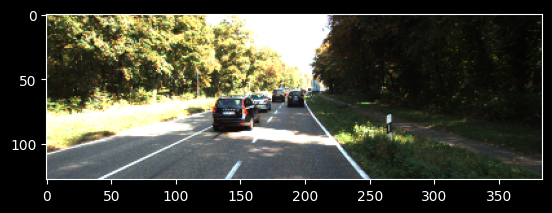

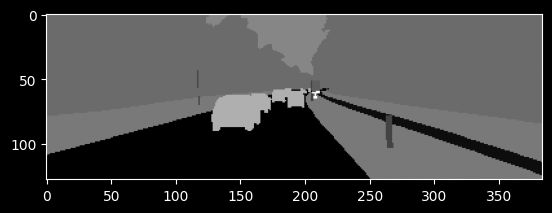

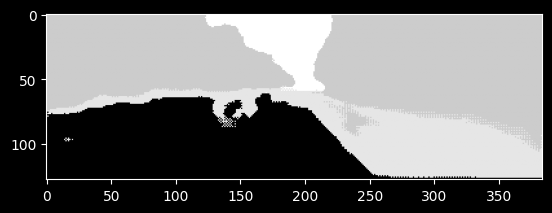

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


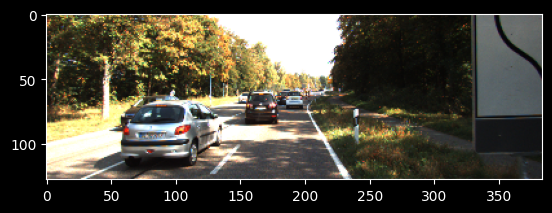

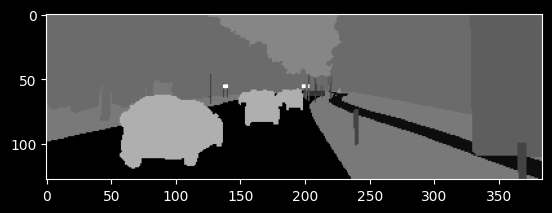

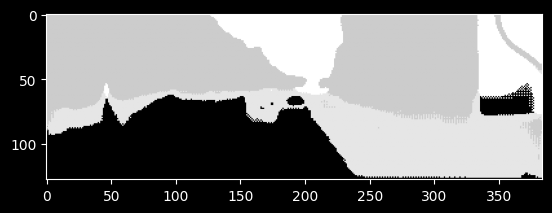

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


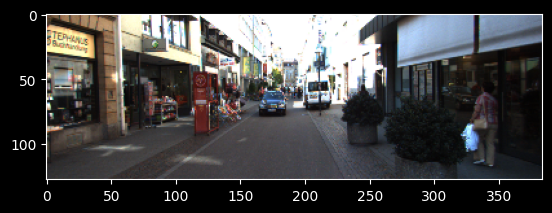

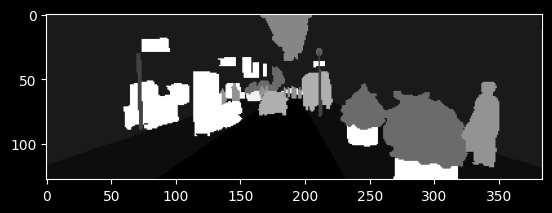

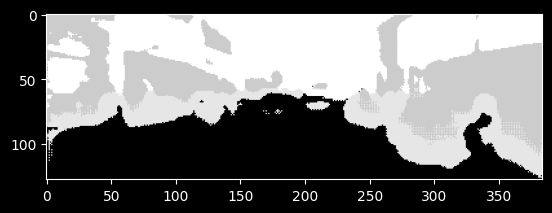

In [88]:
for image, mask in val_ds.take(3):
    prediction = model.predict(image)
    predicted_mask = tf.argmax(prediction, axis=-1)

    plt.imshow(image[0])
    plt.show()
    plt.imshow(tf.squeeze(mask[0]), cmap='gray')
    plt.show()
    plt.imshow(predicted_mask[0], cmap='gray')
    plt.show()

In [90]:
for image, mask in val_ds.take(1):
    prediction = model.predict(image)
    predicted_mask = tf.argmax(prediction, axis=-1)
    print("Unique predictions:", np.unique(predicted_mask[0].numpy()))
    print("Unique ground truth:", np.unique(mask[0].numpy()))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
Unique predictions: [ 0  1  4  5  8  9 10 13 19]
Unique ground truth: [ 0  1  5  7  8  9 10 13 19]
